In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import matplotlib

import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from numpy import array
import sys, webbrowser, datetime


In [2]:
!pip3 install --user --upgrade tensorflow

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
!pip3 install keras


In [4]:
!python --version

Python 3.7.6


In [5]:
!pip install python=3.8

ERROR: Invalid requirement: 'python=3.8'
Hint: = is not a valid operator. Did you mean == ?


In [6]:
print('Python: {}'.format(sys.version))
print('Pandas: {}'.format(pd.__version__))
print('Numpy: {}'.format(np.__version__))
print('Sklearn: {}'.format(sklearn.__version__))


Python: 3.7.6 (default, Jan  8 2020, 20:23:39) [MSC v.1916 64 bit (AMD64)]
Pandas: 1.0.1
Numpy: 1.18.1
Sklearn: 0.22.1


In [7]:
cleveland = pd.read_csv('heart.csv')
print('Shape of DataFrame:{}'.format(cleveland.shape))



Shape of DataFrame:(303, 14)


In [8]:
print (cleveland.loc[1])
data = cleveland[~cleveland.isin(['?'])]

age          67
sex           1
cp            4
trestbps    160
chol        286
fbs           0
restecg       2
thalach     108
exang         1
oldpeak     1.5
slope         2
ca            3
thal          3
target        2
Name: 1, dtype: object


In [9]:
data.loc[280:]
print(data.shape)
print(data.dtypes)

(303, 14)
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca           object
thal         object
target        int64
dtype: object


In [10]:
data = data.apply(pd.to_numeric) # to numberic conversion

In [11]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

In [12]:
data['oldpeak']=data['oldpeak'].fillna(0).astype(np.int64)
data['ca']=data['ca'].fillna(0).astype(np.int64)
data['thal']=data['thal'].fillna(0).astype(np.int64)


In [13]:
data.dtypes

age         int64
sex         int64
cp          int64
trestbps    int64
chol        int64
fbs         int64
restecg     int64
thalach     int64
exang       int64
oldpeak     int64
slope       int64
ca          int64
thal        int64
target      int64
dtype: object

In [14]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,0.765677,1.600660,0.663366,4.702970,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.070933,0.616226,0.934375,1.971038,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.000000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.000000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.000000,3.000000,3.000000,7.000000,4.000000


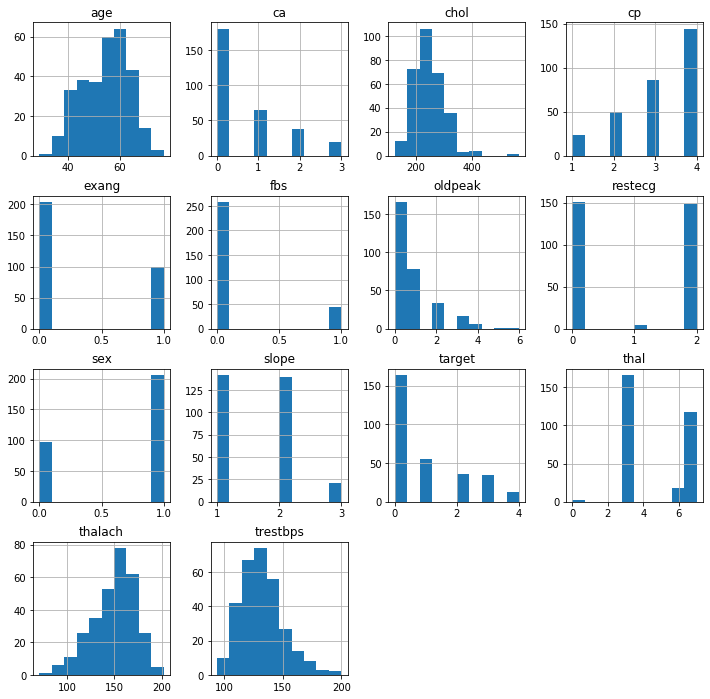

In [15]:
data.hist(figsize = (12, 12))
plt.show()

In [16]:
X = np.array(data.drop(['target'], 1))
y = np.array(data['target'])


In [17]:
X

array([[63,  1,  1, ...,  3,  0,  6],
       [67,  1,  4, ...,  2,  3,  3],
       [67,  1,  4, ...,  2,  2,  7],
       ...,
       [57,  1,  4, ...,  2,  1,  7],
       [57,  0,  2, ...,  2,  1,  3],
       [38,  1,  3, ...,  1,  0,  3]], dtype=int64)

In [18]:
y

array([0, 2, 1, 0, 0, 0, 3, 0, 2, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 3, 4, 0, 0, 0, 0, 3, 0, 2, 1, 0, 0, 0, 3, 1, 3, 0, 4, 0, 0, 0,
       1, 4, 0, 4, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2, 2,
       1, 0, 2, 1, 0, 3, 1, 1, 1, 0, 1, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 0,
       0, 0, 0, 3, 0, 0, 0, 1, 2, 3, 0, 0, 0, 0, 0, 0, 3, 0, 2, 1, 2, 3,
       1, 1, 0, 2, 2, 0, 0, 0, 3, 2, 3, 4, 0, 3, 1, 0, 3, 3, 0, 0, 0, 0,
       0, 0, 0, 0, 4, 3, 1, 0, 0, 1, 0, 1, 0, 1, 4, 0, 0, 0, 0, 0, 0, 4,
       3, 1, 1, 1, 2, 0, 0, 4, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 1, 0, 4, 1,
       0, 1, 0, 0, 3, 2, 0, 0, 1, 0, 0, 2, 1, 2, 0, 3, 1, 2, 0, 3, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 3, 3, 3, 0, 1, 0, 4, 0, 3, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 1, 0, 0, 0, 3, 2, 0, 2, 1, 0, 0, 3, 2, 1, 0, 0, 0, 0,
       0, 2, 0, 2, 2, 1, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0,
       4, 2, 2, 2, 1, 0, 1, 0, 2, 0, 1, 0, 0, 0, 1, 0, 2, 0, 3, 0, 2, 4,
       2, 0, 0, 0, 1, 0, 2, 2, 1, 0, 3, 1, 1, 2, 3,

In [19]:
X_train, X_test, y_train, y_test =sklearn.model_selection.train_test_split(X, y, test_size = 0.2)

In [20]:
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (242, 13) (242,)
Test set: (61, 13) (61,)


In [21]:
# New with modifications
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Dropout
from keras import regularizers
from keras.utils.np_utils import to_categorical

D:\Users\Anaconda3\lib\site-packages\tensorboard\compat\tensorflow_stub\dtypes.py:541: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\Users\Anaconda3\lib\site-packages\tensorboard\compat\tensorflow_stub\dtypes.py:542: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\Users\Anaconda3\lib\site-packages\tensorboard\compat\tensorflow_stub\dtypes.py:543: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\Users\Anaconda3\lib\site-packages\tensorboard\compat\tensorflow_stub\dtypes.py:544: FutureWarning: P

In [22]:
Y_train = to_categorical(y_train, num_classes=None)
Y_test = to_categorical(y_test, num_classes=None)
print (Y_train.shape)
print (Y_train[:10])
def create_model():
    model = Sequential()
    model.add(Dense(16, input_dim=13, kernel_initializer='normal', activation='relu'))
    model.add(Dense(8, kernel_initializer='normal', activation='relu'))
    model.add(Dense(2, activation='softmax'))
# compile model
    adam = Adam(lr=0.001)
    model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
    return model
    model = create_model()
    print(model.summary())
    history=model.fit(X_train, Y_train, validation_data=(X_test, Y_test),epochs=200, batch_size=10,
    verbose = 10)
def create_binary_model():
# create model
    model = Sequential()
    model.add(Dense(16, input_dim=13, kernel_initializer='normal',
    activation='relu'))
    model.add(Dense(8, kernel_initializer='normal', activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
# Compile model
    adam = Adam(lr=0.001)
    model.compile(loss='binary_crossentropy', optimizer=adam,
    metrics=['accuracy'])
    return model









(242, 5)
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


In [23]:
# fit the binary model on the training data
emodel =create_binary_model()
Y_train_binary = y_train.copy()
Y_test_binary = y_test.copy()
history=emodel.fit(X_train, Y_train_binary,
validation_data=(X_test, Y_test_binary), epochs=200, batch_size=10,
verbose = 10)
X_n1 = array([[28,67,89,12,34,56,78,76,54,56,78,90,75]])
y_p = emodel.predict_classes(X_n1)
if y_p == 1:
    print("Heart problem")
    webbrowser.open("https://www.google.com/maps/search/heart+hospital    s+near+me")
else:
    print("Patient is fine")


Epoch 1/200
Epoch 2/200
Epoch 3/200
Epoch 4/200
Epoch 5/200
Epoch 6/200
Epoch 7/200
Epoch 8/200
Epoch 9/200
Epoch 10/200
Epoch 11/200
Epoch 12/200
Epoch 13/200
Epoch 14/200
Epoch 15/200
Epoch 16/200
Epoch 17/200
Epoch 18/200
Epoch 19/200
Epoch 20/200
Epoch 21/200
Epoch 22/200
Epoch 23/200
Epoch 24/200
Epoch 25/200
Epoch 26/200
Epoch 27/200
Epoch 28/200
Epoch 29/200
Epoch 30/200
Epoch 31/200
Epoch 32/200
Epoch 33/200
Epoch 34/200
Epoch 35/200
Epoch 36/200
Epoch 37/200
Epoch 38/200
Epoch 39/200
Epoch 40/200
Epoch 41/200
Epoch 42/200
Epoch 43/200
Epoch 44/200
Epoch 45/200
Epoch 46/200
Epoch 47/200
Epoch 48/200
Epoch 49/200
Epoch 50/200
Epoch 51/200
Epoch 52/200
Epoch 53/200
Epoch 54/200
Epoch 55/200
Epoch 56/200
Epoch 57/200
Epoch 58/200
Epoch 59/200
Epoch 60/200
Epoch 61/200
Epoch 62/200
Epoch 63/200
Epoch 64/200
Epoch 65/200
Epoch 66/200
Epoch 67/200
Epoch 68/200
Epoch 69/200
Epoch 70/200
Epoch 71/200
Epoch 72/200
Epoch 73/200
Epoch 74/200
Epoch 75/200
Epoch 76/200
Epoch 77/200
Epoch 78

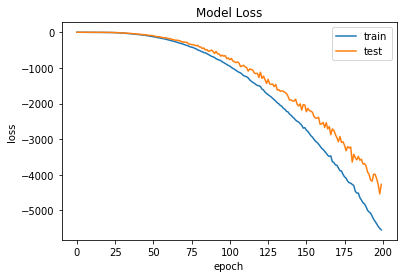

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline

# Model Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
   
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.show()


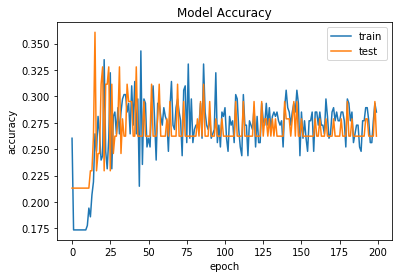

In [25]:
# Model accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.show()

In [26]:
bmodel=create_binary_model()
# generate classification report using predictions for categorical model
from sklearn.metrics import classification_report, accuracy_score
# generate classification report using predictions for binary model
binary_pred = np.round(bmodel.predict(X_test)).astype(int)
print('Results for Binary Model')
print(accuracy_score(Y_test_binary, binary_pred))
print (Y_train[:10])

Results for Binary Model
0.5409836065573771
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


In [27]:
# convert into binary classification problem - outcome
Y_train_binary = y_train.copy()
Y_test_binary = y_test.copy()

Y_train_binary[Y_train_binary > 0] = 1
Y_test_binary[Y_test_binary > 0] = 1

print(Y_train_binary[:768])

[0 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0
 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 0
 0 1 1 1 0 0 1 0 0 1 0 1 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 1 0
 1 0 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0
 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 1 0
 1 1 1 0 0 1 1 0 0 1 0 1 1 0 1 0 0 1 1 0]


In [28]:
# define a new keras model for binary classification
def create_binary_model():
    # create model
    model = Sequential()
    model.add(Dense(80, input_dim=8, kernel_initializer='normal',  kernel_regularizer=regularizers.l2(0.001),activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(80, kernel_initializer='normal',  kernel_regularizer=regularizers.l2(0.001),activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile model
    adam = Adam(lr=0.001)
    model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
    return model

binary_model = create_binary_model()

print(binary_model.summary())

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_6 (Dense)              (None, 80)                720       
_________________________________________________________________
dropout (Dropout)            (None, 80)                0         
_________________________________________________________________
dense_7 (Dense)              (None, 80)                6480      
_________________________________________________________________
dropout_1 (Dropout)          (None, 80)                0         
_________________________________________________________________
dense_8 (Dense)              (None, 1)                 81        
Total params: 7,281
Trainable params: 7,281
Non-trainable params: 0
_________________________________________________________________
None


In [29]:
# fit the binary model on the training data
history=emodel.fit(X_train, Y_train_binary, validation_data=(X_test, Y_test_binary), epochs=200, batch_size=10)

Epoch 1/200
25/25 [==============================] - 0s 5ms/step - loss: 2679.0688 - accuracy: 0.5992 - val_loss: 1780.1273 - val_accuracy: 0.6393
Epoch 2/200
25/25 [==============================] - 0s 4ms/step - loss: 1269.6660 - accuracy: 0.7397 - val_loss: 701.8124 - val_accuracy: 0.7705
Epoch 3/200
25/25 [==============================] - 0s 4ms/step - loss: 905.2434 - accuracy: 0.7727 - val_loss: 553.8827 - val_accuracy: 0.8361
Epoch 4/200
25/25 [==============================] - 0s 3ms/step - loss: 856.0904 - accuracy: 0.7727 - val_loss: 537.5107 - val_accuracy: 0.8525
Epoch 5/200
25/25 [==============================] - 0s 3ms/step - loss: 854.4683 - accuracy: 0.7645 - val_loss: 533.2812 - val_accuracy: 0.8525
Epoch 6/200
25/25 [==============================] - 0s 4ms/step - loss: 842.2415 - accuracy: 0.7686 - val_loss: 537.1777 - val_accuracy: 0.8361
Epoch 7/200
25/25 [==============================] - 0s 3ms/step - loss: 838.3049 - accuracy: 0.7727 - val_loss: 528.9825 - val

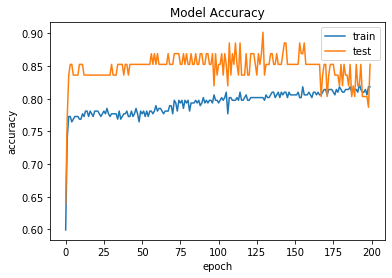

In [30]:

# Model accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.show()